# Trackster EDA

Simple exploration of the cleaned Spotify tracks dataset.

**Prereqs:** run `uv run python -m trackster.download` then `uv run python -m trackster.preprocess` so that `data/processed/tracks_clean.parquet` exists.

Run this notebook with: `uv run --group eda jupyter lab notebooks/eda.ipynb`

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the `trackster` package importable when running from notebooks/.
sys.path.insert(0, str(Path.cwd().parent / "src"))
from trackster.config import PROCESSED_DIR, REPORTS_DIR, ensure_dirs

ensure_dirs()
sns.set_theme(style="whitegrid")

df = pd.read_parquet(PROCESSED_DIR / "tracks_clean.parquet")
print(f"{len(df):,} tracks, {df.shape[1]} columns")
df.head()

586,601 tracks, 11 columns


,id,name,artist_name,artists,id_artists,year,decade,genres,popularity,duration_ms,explicit
0,35iwgR4jXetI318WEWsa1Q,Carve,Uli,[Uli],[45tIt06XoI0Iio4LBEVpls],1922,1920,[],6,126903,0
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,Fernando Pessoa,[Fernando Pessoa],[14jtPCOoNZwquk5wd9DxrY],1922,1920,[],0,98200,0
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,Ignacio Corsini,[Ignacio Corsini],[5LiOoJbxVSAMkBS2fUm3X2],1922,1920,"[tango, vintage tango]",0,181640,0
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,Ignacio Corsini,[Ignacio Corsini],[5LiOoJbxVSAMkBS2fUm3X2],1922,1920,"[tango, vintage tango]",0,176907,0
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,Dick Haymes,[Dick Haymes],[3BiJGZsyX9sJchTqcSA7Su],1922,1920,"[adult standards, big band, easy listening, lo...",0,163080,0


## Overview: schema, dtypes, missing values

In [2]:
df.info()
print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

<class 'pandas.DataFrame'>
RangeIndex: 586601 entries, 0 to 586600
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           586601 non-null  str   
 1   name         586601 non-null  str   
 2   artist_name  586601 non-null  str   
 3   artists      586601 non-null  object
 4   id_artists   586601 non-null  object
 5   year         586601 non-null  Int64 
 6   decade       586601 non-null  Int64 
 7   genres       586601 non-null  object
 8   popularity   586601 non-null  int64 
 9   duration_ms  586601 non-null  int64 
 10  explicit     586601 non-null  int64 
dtypes: Int64(2), int64(3), object(3), str(3)
memory usage: 84.5+ MB

Missing values per column:
id             0
name           0
artist_name    0
artists        0
id_artists     0
year           0
decade         0
genres         0
popularity     0
duration_ms    0
explicit       0
dtype: int64


In [16]:
df.columns

Index(['id', 'name', 'artist_name', 'artists', 'id_artists', 'year', 'decade',
       'genres', 'popularity', 'duration_ms', 'explicit'],
      dtype='str')

In [17]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
year,586601.0,1988.571729,22.826243,1900.0,1974.0,1992.0,2007.0,2021.0
decade,586601.0,1983.988128,22.951706,1900.0,1970.0,1990.0,2000.0,2020.0
popularity,586601.0,27.573212,18.369417,0.0,13.0,27.0,41.0,100.0
duration_ms,586601.0,230054.852626,126532.824981,3344.0,175083.0,214907.0,263867.0,5621218.0
explicit,586601.0,0.044091,0.205298,0.0,0.0,0.0,0.0,1.0


## Tracks per year and per decade

Useful for a 'guess the year / decade' game mode — shows which eras are well covered.

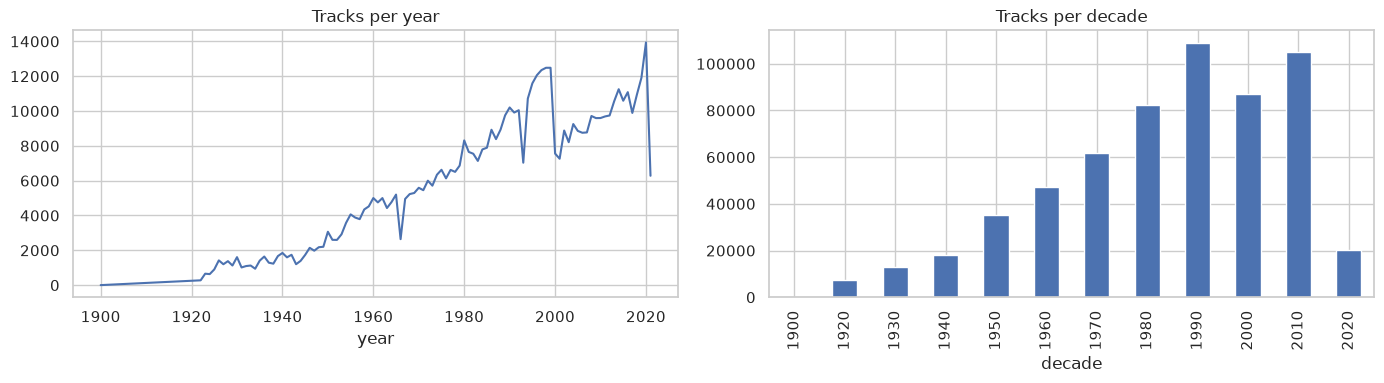

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.groupby("year").size().plot(ax=axes[0], title="Tracks per year")
df.groupby("decade").size().plot(kind="bar", ax=axes[1], title="Tracks per decade")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "tracks_by_time.png", dpi=120)
plt.show()

## Popularity distribution

A popularity threshold is a good way to keep the game to songs people might actually know.

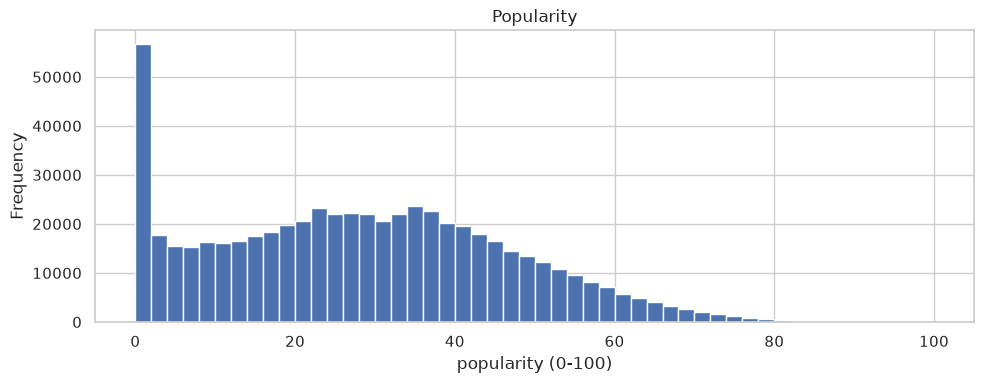

popularity >= 30: 266,571 tracks (45.4%)
popularity >= 50: 75,843 tracks (12.9%)
popularity >= 70: 7,323 tracks (1.2%)


In [7]:
if "popularity" in df.columns:
    ax = df["popularity"].plot(kind="hist", bins=50, figsize=(10, 4), title="Popularity")
    ax.set_xlabel("popularity (0-100)")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "popularity.png", dpi=120)
    plt.show()
    for thr in (30, 50, 70):
        n = (df["popularity"] >= thr).sum()
        print(f"popularity >= {thr}: {n:,} tracks ({n/len(df):.1%})")

In [3]:
populars = df[df['popularity'] > 70]
print(populars['name'].head(40))

30498          Dream A Little Dream Of Me - Single Version
31498    My Baby Just Cares for Me - 2013 Remastered Ve...
31499                                       Jailhouse Rock
32498                                      Johnny B. Goode
33498                                              At Last
33499                                A Sunday Kind Of Love
34498                           Can't Help Falling in Love
35498                                          Stand by Me
35499                                     Oh, Pretty Woman
35500                  Fly Me To The Moon (In Other Words)
36498                    Twist And Shout - Remastered 2009
36499                          Surfin' U.S.A. - Remastered
36500                                         Ring of Fire
36501                                  Blowin' in the Wind
37498              The Sound of Silence - Acoustic Version
37499                         You Really Got Me - Mono Mix
37500                                   You Never Can Te

## Top artists and genres

In [9]:

genres_flat = df.explode('genres')
print(genres_flat['genres'].value_counts())  # count each genre


genres
rock                       32026
adult standards            26688
classic rock               23808
mellow gold                19613
filmi                      19557
                           ...  
native american hip hop        1
pinoy edm                      1
korean superband               1
traditional reggae             1
persian hip hop                1
Name: count, Length: 4672, dtype: int64


In [5]:
popular_songs = df[df['popularity'] > 60]
print(len(popular_songs))

24868


In [24]:

decade_counts = df['decade'].value_counts().sort_index()
print(decade_counts)

decade
1900         1
1920      7592
1930     13024
1940     18021
1950     35363
1960     47262
1970     61840
1980     82322
1990    108872
2000     86841
2010    105245
2020     20218
Name: count, dtype: Int64


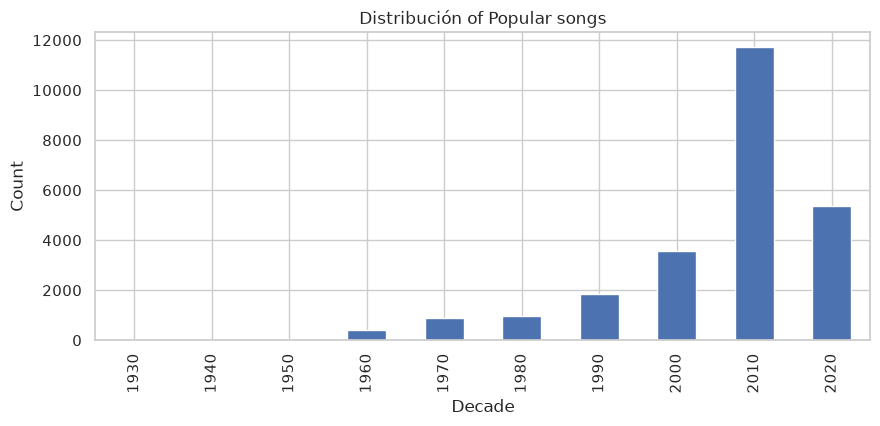

In [25]:
import matplotlib.pyplot as plt

decade_counts = popular_songs['decade'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10,4),
    title='Distribución of Popular songs'
)
plt.xlabel('Decade')
plt.ylabel('Count')
plt.show()

In [6]:
flat = popular_songs.explode('genres')
print(flat['genres'].value_counts())  # count each genre


genres
pop                    5021
dance pop              3564
post-teen pop          2642
rock                   2382
rap                    2336
                       ... 
olympia wa indie          1
gotlandsk musik           1
dansband                  1
skansk musik              1
vintage swedish pop       1
Name: count, Length: 2119, dtype: int64


### Load data to supabase

In [3]:
print(data[0].keys())

dict_keys(['id', 'name', 'artist_name', 'artists', 'id_artists', 'year', 'decade', 'genres', 'popularity', 'duration_ms', 'explicit'])


In [4]:
from supabase import create_client
from trackster.config import SUPABASE_URL, SUPABASE_KEY
import pandas as pd
import numpy as np

# Load cleaned data
df = pd.read_parquet("../data/processed/tracks_clean.parquet")

# Filter popular songs (optional)
df_popular = df[df['popularity'] > 70].copy()
df_popular = df_popular.drop(columns=['id_artists'])

def convert_types(row):
    return {
        k: v.tolist() if isinstance(v, (list, np.ndarray)) else (
            int(v) if isinstance(v, (np.integer, np.int64)) else (
            float(v) if isinstance(v, (np.floating, np.float64)) else (
            bool(v) if isinstance(v, (np.bool_)) else v
            )))
        for k, v in row.items()
    }

# Convert dataframe to records with proper type handling
data = [convert_types(row) for _, row in df_popular.iterrows()]

# Connect to Supabase
print(SUPABASE_URL)
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

# Insert in batches (Supabase has row limits per request)
batch_size = 1000
for i in range(0, len(data), batch_size):
    batch = data[i:i+batch_size]
    response = supabase.table('songs').insert(batch).execute()
    print(f"Inserted {len(batch)} rows ({i}/{len(data)})")

print(f"✓ Total {len(data)} songs loaded to Supabase")


https://tklrgxmteeqlhpmouskk.supabase.co
Inserted 1000 rows (0/6213)
Inserted 1000 rows (1000/6213)
Inserted 1000 rows (2000/6213)
Inserted 1000 rows (3000/6213)
Inserted 1000 rows (4000/6213)
Inserted 1000 rows (5000/6213)
Inserted 213 rows (6000/6213)
✓ Total 6213 songs loaded to Supabase
